# A/B testing a game feature, properly

An A/B test is the only reliable way to know whether a change *caused* an
improvement. Show the new version to a random half of players, keep the old
one for the rest, and compare. Randomising is what removes the "keen players
self-select" problem we saw in the engagement notebook.

But tests are easy to get wrong. This notebook analyses a two-week test of a
new starter-pack offer and covers the parts people skip:

1. Checking the split itself is healthy
2. Testing conversion, with a confidence interval rather than just a p-value
3. Testing revenue, which is much noisier than it looks
4. Working out how many players a test needs *before* running it
5. Why peeking at results every day manufactures false wins

The data is simulated, and we know the truth: the offer really lifts
conversion from 3.0% to 3.45%, and doesn't change how much payers spend.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

from sample_data import game_ab_test

plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(1)
test = game_ab_test()
test.head()

,player_id,group,day_enrolled,converted,spend_usd
0,1,control,1,0,0.0
1,2,variant,8,0,0.0
2,3,control,6,0,0.0
3,4,variant,9,0,0.0
4,5,control,12,0,0.0


## 1. Is the split healthy?

Before looking at any result, check that players were split as designed
(50/50 here). A lopsided split, called a **sample ratio mismatch**, means
something broke in assignment or logging, and the results can't be trusted
however good they look.

In [ ]:
counts = test.group.value_counts()
srm_p = stats.chisquare(counts.values).pvalue
print(counts.to_string())
verdict = "looks fine" if srm_p > 0.01 else "INVESTIGATE before reading results"
print(f"\nSample ratio check p-value: {srm_p:.2f}  ->  {verdict}")

group
variant    30073
control    29927

Sample ratio check p-value: 0.55  ->  looks fine


## 2. Did conversion go up?

In [ ]:
summary = test.groupby("group").agg(players=("player_id", "size"), payers=("converted", "sum"),
                                    revenue=("spend_usd", "sum"))
summary["conversion"] = summary.payers / summary.players
summary["revenue_per_player"] = summary.revenue / summary.players
print(summary.round(4).to_string())

         players  payers   revenue  conversion  revenue_per_player
group                                                             
control    29927     894  12051.02      0.0299              0.4027
variant    30073    1011  12747.62      0.0336              0.4239


The variant converts better, but is the gap real or luck? A two-proportion
z-test gives the p-value. More useful is the **confidence interval for the
difference**: it shows the range of effects consistent with the data, which
is what a decision actually depends on.

In [ ]:
c, v = summary.loc["control"], summary.loc["variant"]
_, p_value = proportions_ztest([v.payers, c.payers], [v.players, c.players])
diff = v.conversion - c.conversion
se = np.sqrt(c.conversion * (1 - c.conversion) / c.players + v.conversion * (1 - v.conversion) / v.players)
low, high = diff - 1.96 * se, diff + 1.96 * se

print(f"Conversion: {c.conversion:.2%} -> {v.conversion:.2%}")
print(f"Difference: {diff * 100:+.2f} percentage points (95% CI {low * 100:+.2f} to {high * 100:+.2f})")
print(f"Relative lift: {diff / c.conversion:+.1%} (95% CI {low / c.conversion:+.1%} to {high / c.conversion:+.1%})")
print(f"p-value: {p_value:.4f}")

Conversion: 2.99% -> 3.36%
Difference: +0.37 percentage points (95% CI +0.09 to +0.66)
Relative lift: +12.5% (95% CI +3.1% to +21.9%)
p-value: 0.0089


The interval sits above zero, so we can be reasonably confident the offer
helps, and the p-value agrees. But look at the width of the interval: the
true lift could be modest or large. If the offer had a real cost (say it
gives away premium currency), you'd want to know the low end still pays for
itself before shipping.

## 3. Did revenue go up?

Revenue per player is what the business cares about, but it's a much harder
metric to test. Most players spend nothing, and a few spend a lot, so a
single big purchase can swing a group's total.

Spend per payer, control $13.48 vs variant $12.61
Biggest single purchase: $217.50; the top 1% of payers bring 10% of revenue



Revenue per player: $0.403 -> $0.424 (+5.3%)
Welch t-test p-value: 0.515
Bootstrap 95% CI for the difference: $-0.043 to $+0.086 per player


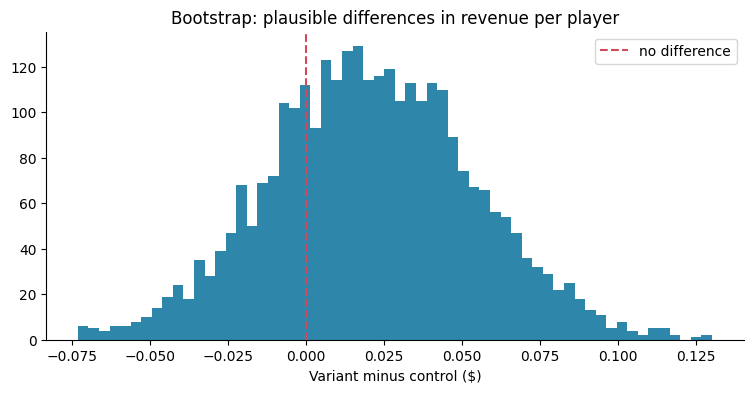

In [ ]:
spend = {g: test.loc[test.group == g, "spend_usd"].to_numpy() for g in ["control", "variant"]}
payer_spend = {g: s[s > 0] for g, s in spend.items()}
print(f"Spend per payer, control ${payer_spend['control'].mean():.2f} vs variant ${payer_spend['variant'].mean():.2f}")
all_payers = np.sort(test.spend_usd[test.converted == 1].to_numpy())[::-1]
print(f"Biggest single purchase: ${all_payers[0]:,.2f}; the top 1% of payers bring "
      f"{all_payers[:len(all_payers) // 100].sum() / all_payers.sum():.0%} of revenue")

welch_p = stats.ttest_ind(spend["variant"], spend["control"], equal_var=False).pvalue

boot_diffs = np.array([rng.choice(spend["variant"], len(spend["variant"])).mean()
                       - rng.choice(spend["control"], len(spend["control"])).mean() for _ in range(3000)])
base_rpp = spend["control"].mean()
print(f"\nRevenue per player: ${base_rpp:.3f} -> ${spend['variant'].mean():.3f} "
      f"({spend['variant'].mean() / base_rpp - 1:+.1%})")
print(f"Welch t-test p-value: {welch_p:.3f}")
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"Bootstrap 95% CI for the difference: ${ci_low:+.3f} to ${ci_high:+.3f} per player")

fig, ax = plt.subplots()
ax.hist(boot_diffs, bins=60, color="#2e86ab")
ax.axvline(0, color="#d1495b", linestyle="--", label="no difference")
ax.set(title="Bootstrap: plausible differences in revenue per player", xlabel="Variant minus control ($)")
ax.legend();

Revenue per player went up in the variant, but the interval comfortably
includes zero and the p-value is nowhere near significant. On revenue alone,
this test can't tell whether the offer helped. That's the heavy tail at
work: spending is so uneven that the same players who gave a clear answer on
conversion give no answer on revenue.

Because we built the data, we know the offer genuinely raises revenue
(through conversion). A team that judged this test on its revenue p-value
would have scrapped a winning feature. The usual remedies are to
pick conversion as the primary metric and treat revenue as a guardrail, cap
extreme values before testing, or simply run the test longer.

## 4. How many players do you need?

Decide this **before** the test. **Power** is the chance a test detects an
effect that's really there; 80% is the usual target. The smaller the effect
and the noisier the metric, the more players you need.

In [ ]:
power = NormalIndPower()
base = 0.030
rows = []
for lift in [0.05, 0.10, 0.15, 0.25]:
    effect = proportion_effectsize(base * (1 + lift), base)
    n_per_group = power.solve_power(effect_size=effect, alpha=0.05, power=0.8)
    rows.append({"relative lift": f"{lift:.0%}", "players per group": f"{n_per_group:,.0f}"})
print(f"Players needed per group to detect a lift from a {base:.0%} baseline (80% power, 5% significance):")
print(pd.DataFrame(rows).to_string(index=False))

achieved = power.power(effect_size=proportion_effectsize(0.0345, 0.030), nobs1=counts.min(), alpha=0.05)
print(f"\nThis test had {counts.min():,} players per group: {achieved:.0%} power for the true 15% lift.")

Players needed per group to detect a lift from a 3% baseline (80% power, 5% significance):
relative lift players per group
           5%           207,908
          10%            53,182
          15%            24,165
          25%             9,073

This test had 29,927 players per group: 88% power for the true 15% lift.


Halving the effect you want to detect roughly quadruples the players you
need. That's why small games struggle to test small tweaks, and why it pays
to test bold changes. If a test is underpowered, a "no significant
difference" result means "we couldn't tell", not "it doesn't work".

## 5. The peeking problem

It's tempting to check results every day and stop as soon as p < 0.05. Let's
see what that does to an **A/A test**, where both groups get the same
experience and any "win" is false.

In [ ]:
def peeking_false_positive_rate(n_tests=1000, days=14, players_per_day=2000, rate=0.03):
    stopped_early, waited = 0, 0
    for _ in range(n_tests):
        a = rng.binomial(players_per_day, rate, days).cumsum()
        b = rng.binomial(players_per_day, rate, days).cumsum()
        n = players_per_day * np.arange(1, days + 1)
        pooled = (a + b) / (2 * n)
        z = (b / n - a / n) / np.sqrt(pooled * (1 - pooled) * 2 / n)
        significant = np.abs(z) > 1.96
        stopped_early += significant.any()  # stop the first day it looks significant
        waited += significant[-1]           # only look once, at the planned end
    return stopped_early / n_tests, waited / n_tests


peek, planned = peeking_false_positive_rate()
print(f"False 'wins' when checking once at the end:   {planned:.1%}")
print(f"False 'wins' when checking daily and stopping: {peek:.1%}")

False 'wins' when checking once at the end:   5.0%
False 'wins' when checking daily and stopping: 23.7%


Checking once gives the promised 5% false-positive rate. Checking daily and
stopping at the first significant result inflates it several times over,
because random noise drifts across the threshold at some point surprisingly
often. The fixes: fix the sample size in advance and look once, or use a
method built for continuous monitoring (sequential testing).

## Takeaways

- Check the split (sample ratio mismatch) before reading any result.
- Report a confidence interval for the effect, not just a p-value.
- Revenue is heavy-tailed and needs much bigger tests than conversion.
- Calculate the sample size first; "not significant" in a small test means "can't tell".
- Don't stop a test the moment it looks significant.